In [4]:
# 한글 설치
!apt-get update -qq
!apt-get install -qq fonts-nanum

# 설치 후 런타임 다시 시작

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [1]:
!rm -rf ~/.cache/matplotlib

In [2]:
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font = fm.FontProperties(fname=font_path)
print(font.get_name())

NanumGothic


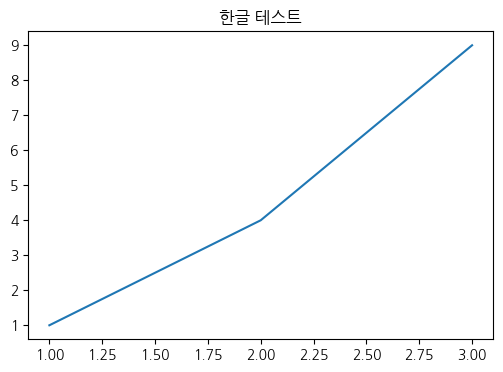

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', family=font.get_name())
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6, 4))
plt.title('한글 테스트')
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()


# 결측치 시각화를 위한 라이브러리
import missingno

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

# 프로젝트 셋팅

In [6]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = '/content/drive/MyDrive/파이널 프로젝트/model/best_model_All_PCA(10)_split.dat'
# 교차검증 횟수
cv_count = 5
# 교차 검증
kfold = KFold(n_splits=cv_count, shuffle=True, random_state=1)
# 평가 결과를 담을 리스트
# 필요하다면 다른 것도 만들어주세요
f1_score_list = []
# 학습 모델 이름
model_name_list = []

# 데이터 준비

In [7]:
# 데이터 읽어온다
train_df = pd.read_parquet('/content/drive/MyDrive/파이널 프로젝트/pca_train.parquet')
test_df = pd.read_parquet('/content/drive/MyDrive/파이널 프로젝트/pca_test.parquet')

display(train_df)
display(test_df)

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,Segment
0,-2243.552932,73177.822751,-23307.067101,7561.747681,-3243.689945,4528.594709,-4408.328899,8369.204848,-6309.014637,1232.178489,D
1,-4123.593576,-18596.799844,-5281.553927,552.003969,2047.728561,2851.121294,-2005.535562,3877.903213,-889.924578,3031.998141,E
2,93844.494983,123215.256247,-21110.839099,-7111.076140,-5582.733394,13547.760968,-1048.762695,9425.227218,1943.737286,-143.578502,C
3,10648.448210,115700.176919,-21742.094578,11510.390683,-7770.532197,-7559.367414,-5333.651779,13026.736618,-76.952366,259.298026,D
4,-76132.442560,-2534.422667,-1881.492818,724.219681,-55.011442,-2366.802627,-931.083210,71.543289,-16.547835,-290.180409,E
...,...,...,...,...,...,...,...,...,...,...,...
2399995,-70708.144660,-4606.543015,2805.802812,-7312.121123,-3526.939822,-4965.947915,220.135110,1057.678514,2360.636905,1934.651583,E
2399996,140275.356531,814.052456,-29512.108763,23504.905496,-9175.280458,5675.125390,16409.620661,2465.542079,-4928.311456,2604.849953,D
2399997,17590.595794,3334.474385,5996.492941,645.269906,-4197.372201,1762.693539,-60.440878,2115.391055,-919.578187,2820.212873,C
2399998,-75089.653850,-3665.731945,-3620.020117,709.662982,42.502434,-1556.732214,-1652.830373,84.509015,-302.824774,-692.984228,E


,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10
0,5449.770399,-15457.518923,7975.048624,-2971.418082,-1137.004720,4011.962214,11551.144045,3357.707219,-2924.619961,-1328.630829
1,-39956.605716,26232.031295,1163.543135,-8719.802068,-6359.839526,-9991.101935,-4302.131549,15137.268688,10291.412329,815.171496
2,91343.368168,20400.129647,49117.164561,18297.225673,-3701.289750,445.182607,-8089.748593,9430.604063,-8090.458211,-63.631244
3,-60622.721453,-2779.211142,172.147101,-1520.579240,494.335640,-2245.292728,-2498.491927,4213.196652,2446.223055,-925.403803
4,-48203.789469,188.499891,8676.875441,-8345.019485,-4152.234122,-8421.964890,-2943.931765,4537.336623,1748.248608,-1903.155119
...,...,...,...,...,...,...,...,...,...,...
599995,-75126.065178,-3705.200669,-3607.179085,706.459161,88.174555,-1576.755865,-1673.193124,66.734119,-311.373335,-693.622302
599996,-69393.140779,-2960.239513,-1778.824780,-236.728841,-975.862257,-3279.293100,-1335.075257,1572.949223,733.136011,-850.853958
599997,-75112.821137,-3689.619019,-3601.622699,707.283479,73.604402,-1557.581432,-1663.292202,80.980237,-310.201036,-691.082195
599998,429765.434664,-147776.679157,-45333.927657,-79709.429111,-51300.598712,-19337.740260,4039.117738,2184.738332,42456.455292,14162.848902


### Split

In [8]:
# 라벨 인코더 생성
le = LabelEncoder()

# 문자열 y를 숫자로 변환
train_df['Segment'] = le.fit_transform(train_df['Segment'])

In [9]:
# Train / Validation Split
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42)

In [14]:
# Feature / Target 분리
train_X = train_data.drop('Segment', axis=1)
train_y = train_data['Segment']

val_X = val_data.drop('Segment', axis=1)
val_y = val_data['Segment']


In [15]:
scalerX = StandardScaler()
train_X_scaled = scalerX.fit_transform(train_X)
val_X_scaled = scalerX.transform(val_X)


In [16]:
test_X = test_df.copy()
test_X_scaled = scalerX.transform(test_X)
# test_y는 없음 (현재 데이터 기준)

# 기본 모델 사용하기

In [17]:
# LGBM
lgbm_basic_model = LGBMClassifier(verbose=-1)
# 교차 검증을 수행한다
r1 = cross_val_score(lgbm_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)
# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())
# 학습 모델 이름을 담아준다.
model_name_list.append("LGBM Basic")

In [18]:
# XGBoost 모델 생성 (verbosity=0: 출력 최소화)
xgboost_basic_model = XGBClassifier(verbosity=0)

# kfold는 미리 정의된 KFold 객체라고 가정
r1 = cross_val_score(xgboost_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)

# 평가 결과를 담아준다.
f1_score_list.append(r1.mean())

# 학습 모델 이름을 담아준다.
model_name_list.append("XGBoost Basic")

In [33]:
# LGBM (클래스 가중치 적용)
lgbm_basic_model_balanced = LGBMClassifier(verbose=-1, class_weight='balanced')

# 교차 검증 수행
r1 = cross_val_score(lgbm_basic_model, train_X, train_y, scoring='f1_micro', cv=kfold)

# 평가 결과 저장
f1_score_list.append(r1.mean())
model_name_list.append("LGBM Balanced")

In [34]:
d1 = {
    'f1 score' : f1_score_list
}
result_df = pd.DataFrame(d1, index=model_name_list)
result_df.sort_values(by='f1 score', ascending=False, inplace=True)
result_df

,f1 score
XGBoost Basic,0.865044
LGBM Basic,0.859373
LGBM Balanced,0.797041
LGBM Balanced,0.797041


In [20]:
final_model=xgboost_basic_model.fit(train_X, train_y)

In [21]:
import pickle

# 저장할 파일 경로
best_model_path = '/content/drive/MyDrive/파이널 프로젝트/model/best_model_All_PCA(10_split.dat'

# 💾 저장
with open(best_model_path, 'wb') as fp:
    pickle.dump(final_model, fp)
    pickle.dump(scalerX, fp)
    pickle.dump(le, fp)

print("✅ 모델과 스케일러, 인코더 저장 완료!")

✅ 모델과 스케일러, 인코더 저장 완료!


In [22]:
# 학습이 완료된 모델을 저장할 파일 이름
best_model_path = '/content/drive/MyDrive/파이널 프로젝트/model/best_model_All_PCA(10_split.dat'
# 예측 결과를 저장할 파일 이름
prediction_path = '/content/drive/MyDrive/파이널 프로젝트/model/best_model_All_PCA(10_split.csv'

In [23]:
with open(best_model_path, 'rb') as fp:
    loaded_model = pickle.load(fp)
    loaded_scalerX = pickle.load(fp)
    loaded_le = pickle.load(fp)

print("✅ 모델, 스케일러, 인코더 불러오기 완료!")

display(loaded_model)
display(loaded_scalerX)
display(loaded_le)

✅ 모델, 스케일러, 인코더 불러오기 완료!


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

StandardScaler()

LabelEncoder()

In [24]:
val_X = val_data.drop('Segment', axis=1)
val_y = val_data['Segment']


In [25]:
# 스케일 transform
val_X_scaled = scalerX.transform(val_X)

In [26]:
# 예측
y_pred_val = final_model.predict(val_X_scaled)

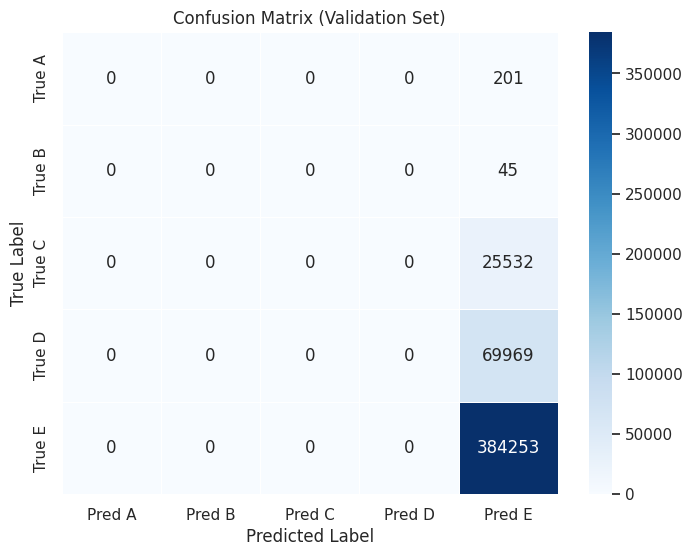

In [28]:
from sklearn.metrics import confusion_matrix

# confusion matrix 계산
cm = confusion_matrix(val_y, y_pred_val)

# DataFrame 변환 (가독성 ↑)
cm_df = pd.DataFrame(
    cm,
    index=[f'True {label}' for label in le.classes_],
    columns=[f'Pred {label}' for label in le.classes_]
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Confusion Matrix (Validation Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()